# F26-10 | Phase 3: Model Building & Initial Results
## AI-Powered Material Estimation & Recommendation System


---
## Overview

The notebook implements two AI sub-systems:

| Sub-system | Task | Algorithm |
|---|---|---|
| **Estimation Engine** | Predict clips, grout volume, grout tubes | Random Forest Regressor |
| **Grout Colour Recommender** | Predict seamless / balanced / contrast grout colour | Random Forest Classifier |

**Why Random Forest?**  
- Handles mixed numeric + one-hot categorical features without extra scaling  
- Robust to the moderate dataset size (200 rows) — avoids overfitting vs. deep nets  
- Built-in feature importance aids interpretability  
- Supports both regression (material quantities) and classification (colour labels) under one unified framework

---
## 1. Imports & Libraries

In [1]:
import pandas as pd
import numpy as np
import random
import math
import colorsys
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
import joblib

print("All libraries imported successfully.")

All libraries imported successfully.


---
## 2. Dataset Re-Generation (from Phase 2)

The Phase 2 dataset pipeline is reproduced here to ensure continuity.  
All helper functions, estimation logic, and colour recommendation rules are carried forward without modification.

In [13]:
# Unit conversion helpers

def sqm_to_sqft(area_sqm):   return area_sqm * 10.7639
def cm_to_inch(length_cm):   return length_cm / 2.54
def sutar_to_mm(sutar):      return sutar * 3.175
def inch_to_meter(x):        return x * 0.0254
def mm_to_meter(x):          return x / 1000
def sqft_to_sqm(area_sqft):  return area_sqft * 0.092903

# Clip lookup table

clip_lookup = {
    (4,4):1981,(6,4):1318,(6,6):877,(8,4):496,(8,6):329,(8,8):491,
    (10,4):398,(10,6):264,(10,8):390,(10,10):313,(12,4):660,(12,6):439,
    (12,8):489,(12,10):390,(12,12):430,(16,4):496,(16,6):329,(16,8):366,
    (16,10):292,(16,12):323,(16,16):241,(18,4):441,(18,6):293,(18,8):325,
    (18,10):259,(18,12):286,(18,16):214,(18,18):190,(20,4):397,(20,6):264,
    (20,8):292,(20,10):233,(20,12):257,(20,16):192,(20,18):170,(20,20):153,
    (22,4):361,(22,6):240,(22,8):265,(22,10):212,(22,12):233,(22,16):174,
    (22,18):155,(22,20):139,(22,22):126,(24,4):332,(24,6):220,(24,8):243,
    (24,10):194,(24,12):213,(24,16):159,(24,18):142,(24,20):127,(24,22):115,
    (24,24):106,(30,4):396,(30,6):264,(30,8):259,(30,10):207,(30,12):213,
    (30,16):160,(30,18):141,(30,20):128,(30,22):116,(30,24):105,(30,30):98,
    (32,4):372,(32,6):247,(32,8):242,(32,10):193,(32,12):199,(32,16):149,
    (32,18):132,(32,20):118,(32,22):108,(32,24):98,(32,30):94,(32,32):88,
    (35,4):328,(35,6):221,(35,8):215,(35,10):170,(35,12):177,(35,16):132,
    (35,18):117,(35,20):106,(35,22):95,(35,24):87,(35,30):83,(35,32):78,(35,35):69,
    (40,4):300,(40,6):198,(40,8):193,(40,10):154,(40,12):158,(40,16):117,
    (40,18):105,(40,20):94,(40,22):85,(40,24):78,(40,30):74,(40,32):69,
    (40,35):62,(40,40):55,(48,4):332,(48,6):220,(48,8):200,(48,10):161,
    (48,12):159,(48,16):118,(48,18):106,(48,20):95,(48,22):86,(48,24):79,
    (48,30):72,(48,32):67,(48,35):60,(48,40):53,(48,48):50
}

def get_clips_per_100sqft(l, w):
    key = (max(l, w), min(l, w))
    if key in clip_lookup: return clip_lookup[key]
    raise ValueError(f"Invalid tile size: {l}x{w}")

def calculate_clips(area_sqft, l, w):
    return math.ceil((area_sqft / 100) * get_clips_per_100sqft(l, w))

def calculate_grout_volume_ml(area_sqft, l_in, w_in, gw_mm, th_mm, wastage=1.15):
    area_sqm  = sqft_to_sqm(area_sqft)
    l_m, w_m  = inch_to_meter(l_in), inch_to_meter(w_in)
    gw_m, th_m = mm_to_meter(gw_mm), mm_to_meter(th_mm)
    vol_m3 = area_sqm * ((l_m + w_m) / (l_m * w_m)) * gw_m * th_m * wastage
    return vol_m3 * 1_000_000

def calculate_grout_tubes(vol_ml): return math.ceil(vol_ml / 330)

def min_grout_width_by_tile(l_in):
    if   4  <= l_in <= 10: return 1.5
    elif 12 <= l_in <= 22: return 2.0
    elif 24 <= l_in <= 32: return 2.5
    elif 36 <= l_in <= 48: return 3.0
    raise ValueError("Tile length out of range")

def min_grout_width_by_location(loc):
    return {"floor": 2.0, "inside_wall": 1.5, "outside_wall": 2.5}[loc]

def get_min_grout_width(l_in, loc):
    return max(min_grout_width_by_tile(l_in), min_grout_width_by_location(loc))

# Colour helpers

dropdown_to_hex = {
    "white":"#FFFFFF","ivory":"#FFFFF0","beige":"#F5F5DC","light_gray":"#D3D3D3",
    "dark_gray":"#A9A9A9","black":"#000000","wood":"#8B5A2B","chocolate":"#7B3F00"
}

def hex_to_rgb(h):
    h = h.lstrip("#")
    return tuple(int(h[i:i+2],16) for i in (0,2,4))

def get_lightness(h):
    r,g,b = hex_to_rgb(h)
    b_ = 0.299*r + 0.587*g + 0.114*b
    return "dark" if b_<85 else "medium" if b_<170 else "light"

def get_tone(h):
    r,g,b = hex_to_rgb(h)
    hue,s,v = colorsys.rgb_to_hsv(r/255,g/255,b/255)
    deg = hue*360
    if s<0.15: return "neutral"
    if 0<=deg<=70 or deg>=330: return "warm"
    if 160<=deg<=260: return "cool"
    return "neutral"

available_colors = [
    {"name":"bright_white","hex":"#FFFFFF","tone":"neutral","lightness":"light"},
    {"name":"glossy_black","hex":"#000000","tone":"neutral","lightness":"dark"},
    {"name":"light_grey",  "hex":"#D3D3D3","tone":"cool",   "lightness":"light"},
    {"name":"brown",       "hex":"#8B4513","tone":"warm",   "lightness":"dark"},
    {"name":"beige",       "hex":"#F5F5DC","tone":"warm",   "lightness":"light"},
    {"name":"ivory",       "hex":"#FFFFF0","tone":"warm",   "lightness":"light"},
    {"name":"golden",      "hex":"#DAA520","tone":"warm",   "lightness":"medium"},
]

def generate_primary_recommendations(tile_hex, lightness, tone):
    seamless = None; min_diff = float("inf")
    for c in available_colors:
        if c["tone"]==tone or c["tone"]=="neutral":
            cv = 1 if c["lightness"]=="light" else 0.5 if c["lightness"]=="medium" else 0
            tv = 1 if lightness=="light" else 0.5 if lightness=="medium" else 0
            d = abs(cv-tv)
            if d<min_diff: min_diff=d; seamless=c
    if seamless is None or min_diff>0.5: seamless=-1
    else: seamless={"hex":seamless["hex"],"lightness":seamless["lightness"]}
    balanced = "light_grey" if tone=="cool" else random.choice(["beige","ivory"]) if tone=="warm" else random.choice(["light_grey","beige","ivory"])
    if   lightness=="light": contrast=random.choice(["glossy_black","brown","light_grey"])
    else: contrast=random.choice(["bright_white","ivory"])
    if tone=="warm" and lightness=="dark" and random.random()<0.3: contrast="golden"
    return {"seamless":seamless,"balanced":balanced,"contrast":contrast}

print("Helper functions defined.")

Helper functions defined.


In [14]:
# Generate dataset (same seed as Phase 2)

random.seed(42)
np.random.seed(42)

areas       = [100, 500, 1000, 5000, 10000, 20000]
tile_sizes  = [4, 6, 8, 10, 12, 16, 24, 32, 48]
locations   = ["floor", "inside_wall", "outside_wall"]
tile_colors = list(dropdown_to_hex.keys())

data = []
for _ in range(200):
    area = random.choice(areas)
    tl   = random.choice(tile_sizes)
    tw   = random.choice(tile_sizes)
    th   = round(random.uniform(6.4, 13), 2)
    loc  = random.choice(locations)

    if random.random() < 0.7:
        tile_hex = dropdown_to_hex[random.choice(tile_colors)]
    else:
        tile_hex = "#{:06X}".format(random.randint(0, 0xFFFFFF))

    lightness = get_lightness(tile_hex)
    tone      = get_tone(tile_hex)

    clips       = calculate_clips(area, tl, tw)
    gw          = get_min_grout_width(tl, loc)
    grout_vol   = calculate_grout_volume_ml(area, tl, tw, gw, th)
    grout_tubes = calculate_grout_tubes(grout_vol)
    primary     = generate_primary_recommendations(tile_hex, lightness, tone)

    data.append({
        "area_sqft":        area,
        "tile_length_in":   tl,
        "tile_width_in":    tw,
        "tile_thickness_mm":th,
        "location":         loc,
        "tile_hex":         tile_hex,
        "lightness":        lightness,
        "tone":             tone,
        "clips":            clips,
        "grout_volume_ml":  round(grout_vol, 4),
        "grout_tubes":      grout_tubes,
        "seamless_primary": primary["seamless"],
        "balanced_primary": primary["balanced"],
        "contrast_primary": primary["contrast"],
    })

df_raw = pd.DataFrame(data)
print(f" Dataset generated: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
df_raw.head(3)

 Dataset generated: 200 rows × 14 columns


,area_sqft,tile_length_in,tile_width_in,tile_thickness_mm,location,tile_hex,lightness,tone,clips,grout_volume_ml,grout_tubes,seamless_primary,balanced_primary,contrast_primary
0,20000,6,4,11.29,floor,#FFFFF0,light,neutral,263600,791473.8192,2399,"{'hex': '#FFFFFF', 'lightness': 'light'}",ivory,light_grey
1,10000,6,24,6.61,floor,#FFFFFF,light,neutral,22000,115846.8101,352,"{'hex': '#FFFFFF', 'lightness': 'light'}",ivory,glossy_black
2,20000,48,24,7.85,outside_wall,#FFFFFF,light,neutral,15800,123821.1367,376,"{'hex': '#FFFFFF', 'lightness': 'light'}",light_grey,light_grey


---
## 3. Preprocessing for Model Training

In [15]:
df = df_raw.copy()

# Encode seamless (dict → label, -1 stays -1)
color_to_label = {"bright_white":0,"glossy_black":1,"light_grey":2,
                   "brown":3,"beige":4,"ivory":5,"golden":6}

def encode_primary(val):
    if val == -1 or val is None: return -1
    if isinstance(val, dict):    return -1          # no name key → fallback
    return color_to_label.get(val, -1)

for col in ["seamless_primary", "balanced_primary", "contrast_primary"]:
    df[col] = df[col].apply(encode_primary)

# One-hot encode location, tone, lightness
df = pd.get_dummies(df, columns=["location", "tone", "lightness"])

# Drop non-numeric / non-feature columns
df.drop(columns=["tile_hex"], inplace=True)

print("Columns after preprocessing:")
print(df.columns.tolist())
print(f"Shape: {df.shape}")
df.head(3)

Columns after preprocessing:
['area_sqft', 'tile_length_in', 'tile_width_in', 'tile_thickness_mm', 'clips', 'grout_volume_ml', 'grout_tubes', 'seamless_primary', 'balanced_primary', 'contrast_primary', 'location_floor', 'location_inside_wall', 'location_outside_wall', 'tone_cool', 'tone_neutral', 'tone_warm', 'lightness_dark', 'lightness_light', 'lightness_medium']
Shape: (200, 19)


,area_sqft,tile_length_in,tile_width_in,tile_thickness_mm,clips,grout_volume_ml,grout_tubes,seamless_primary,balanced_primary,contrast_primary,location_floor,location_inside_wall,location_outside_wall,tone_cool,tone_neutral,tone_warm,lightness_dark,lightness_light,lightness_medium
0,20000,6,4,11.29,263600,791473.8192,2399,-1,5,2,True,False,False,False,True,False,False,True,False
1,10000,6,24,6.61,22000,115846.8101,352,-1,5,1,True,False,False,False,True,False,False,True,False
2,20000,48,24,7.85,15800,123821.1367,376,-1,2,2,False,False,True,False,True,False,False,True,False


---
## 4. Feature / Target Splits

The system has **two separate model groups**:
- **Regression models** → predict continuous material quantities  
- **Classification models** → predict discrete grout colour labels

In [5]:
# Input features (shared by both sub-systems)
feature_cols = [
    "area_sqft", "tile_length_in", "tile_width_in", "tile_thickness_mm",
    "location_floor", "location_inside_wall", "location_outside_wall",
    "tone_cool", "tone_neutral", "tone_warm",
    "lightness_dark", "lightness_light", "lightness_medium"
]
# Keep only columns that actually exist (some one-hot cols may be absent if never sampled)
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols]

# Regression targets
reg_targets = ["clips", "grout_volume_ml", "grout_tubes"]
y_reg = df[reg_targets]

# Classification targets (filter rows where label != -1 for each target)
cls_targets = ["balanced_primary", "contrast_primary"]
# Note: seamless_primary has -1 entries (no match), so we train balanced & contrast only

print(f"Feature matrix : {X.shape}")
print(f"Regression targets: {reg_targets}")
print(f"Classification targets: {cls_targets}")

Feature matrix : (200, 13)
Regression targets: ['clips', 'grout_volume_ml', 'grout_tubes']
Classification targets: ['balanced_primary', 'contrast_primary']


In [6]:
# Train / Test Split
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print(f"Train size : {X_train.shape[0]}")
print(f"Test  size : {X_test.shape[0]}")

Train size : 160
Test  size : 40


---
## 5. Sub-System A — Regression (Material Estimation)

**Algorithm:** `RandomForestRegressor`  
**Hyperparameters:**
- `n_estimators=200` — 200 decision trees averaged together  
- `max_depth=10` — limits overfitting on the small dataset  
- `min_samples_leaf=2` — ensures each leaf has at least 2 samples  
- `random_state=42` — reproducibility

In [7]:
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train, y_reg_train)
y_pred_reg = rf_reg.predict(X_test)

print("\n📊 Regression Results (Test Set)")
print(f"{'Target':<20} {'MAE':>10} {'RMSE':>12} {'R²':>8}")
print("-"*52)

for i, col in enumerate(reg_targets):
    y_true = y_reg_test[col].values
    y_pr   = y_pred_reg[:, i]
    mae  = mean_absolute_error(y_true, y_pr)
    rmse = np.sqrt(mean_squared_error(y_true, y_pr))
    r2   = r2_score(y_true, y_pr)
    print(f"{col:<20} {mae:>10.2f} {rmse:>12.2f} {r2:>8.4f}")


📊 Regression Results (Test Set)
Target                      MAE         RMSE       R²
----------------------------------------------------
clips                   7464.35     13985.25   0.7004
grout_volume_ml        36634.12     81386.21   0.7676
grout_tubes              111.05       246.64   0.7676


In [8]:
# Cross-Validation (5-fold) on clips
cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=-1),
    X, y_reg["clips"], cv=5, scoring="r2"
)
print(f"5-Fold CV R² for 'clips': {cv_scores.round(4)} | Mean: {cv_scores.mean():.4f}")

5-Fold CV R² for 'clips': [0.5195 0.4838 0.7476 0.9612 0.1546] | Mean: 0.5733


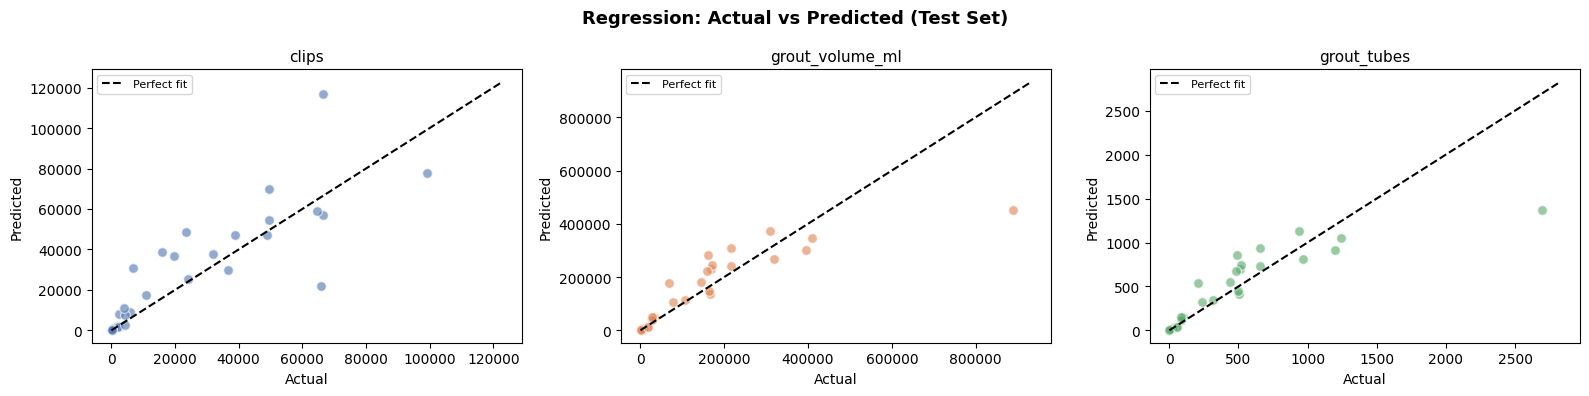

Plot saved.


In [9]:
# Actual vs Predicted plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Regression: Actual vs Predicted (Test Set)", fontsize=13, fontweight="bold")

colors = ["#4C72B0", "#DD8452", "#55A868"]
for i, (col, ax, c) in enumerate(zip(reg_targets, axes, colors)):
    y_true = y_reg_test[col].values
    y_pr   = y_pred_reg[:, i]
    ax.scatter(y_true, y_pr, alpha=0.6, color=c, edgecolors="white", s=50)
    lim = [min(y_true.min(), y_pr.min())*0.9, max(y_true.max(), y_pr.max())*1.05]
    ax.plot(lim, lim, 'k--', lw=1.5, label="Perfect fit")
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("regression_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

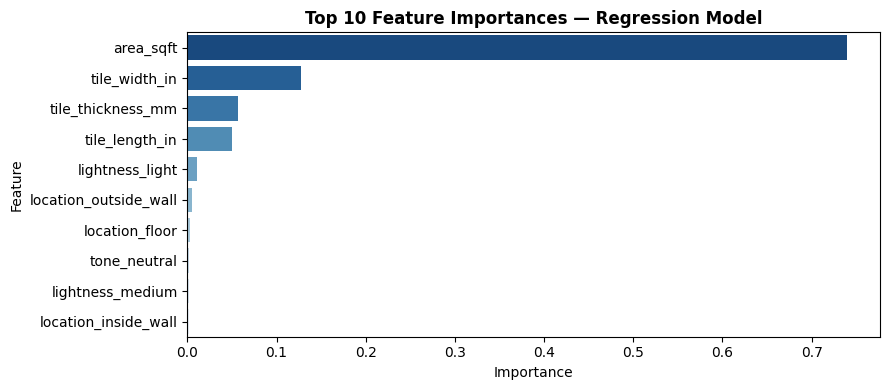

In [10]:
# Feature Importance (Regression)
importances = rf_reg.feature_importances_
feat_df = pd.DataFrame({"Feature": feature_cols, "Importance": importances})
feat_df = feat_df.sort_values("Importance", ascending=False).head(10)

plt.figure(figsize=(9, 4))
sns.barplot(data=feat_df, x="Importance", y="Feature", palette="Blues_r")
plt.title("Top 10 Feature Importances — Regression Model", fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance_regression.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Sub-System B — Classification (Grout Colour Recommender)

**Algorithm:** `RandomForestClassifier`  
**Targets:** `balanced_primary` and `contrast_primary` grout colour labels  
**Why separate classifiers?** Each aesthetic mode (balanced, contrast) follows its own recommendation logic and therefore has a distinct decision boundary.

In [18]:
label_names = ["bright_white","glossy_black","light_grey","brown","beige","ivory","golden"]

clf_results = {}

for target in cls_targets:
    y_cls = df[target]
    mask  = y_cls != -1
    X_cls, y_cls = X[mask], y_cls[mask]

    X_tr, X_te, y_tr, y_te = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_tr, y_tr)
    y_pr = clf.predict(X_te)
    acc  = accuracy_score(y_te, y_pr)
    clf_results[target] = {"model": clf, "X_te": X_te, "y_te": y_te, "y_pr": y_pr, "acc": acc}

    present_labels = sorted(y_cls.unique())
    present_names  = [label_names[l] for l in present_labels if l < len(label_names)]

    print(f"\n- Target: {target}")
    print(f" - Accuracy: {acc:.4f}")
    print(classification_report(y_te, y_pr, labels=present_labels, target_names=present_names, zero_division=0))


- Target: balanced_primary
 - Accuracy: 0.5250
              precision    recall  f1-score   support

  light_grey       0.50      0.71      0.59        14
       beige       0.58      0.50      0.54        14
       ivory       0.50      0.33      0.40        12

    accuracy                           0.53        40
   macro avg       0.53      0.52      0.51        40
weighted avg       0.53      0.53      0.51        40


- Target: contrast_primary
 - Accuracy: 0.3000
              precision    recall  f1-score   support

bright_white       0.29      0.36      0.32        11
glossy_black       0.00      0.00      0.00         5
  light_grey       0.00      0.00      0.00         4
       brown       0.46      0.86      0.60         7
       ivory       0.25      0.17      0.20        12
      golden       0.00      0.00      0.00         1

    accuracy                           0.30        40
   macro avg       0.17      0.23      0.19        40
weighted avg       0.23      0.30  

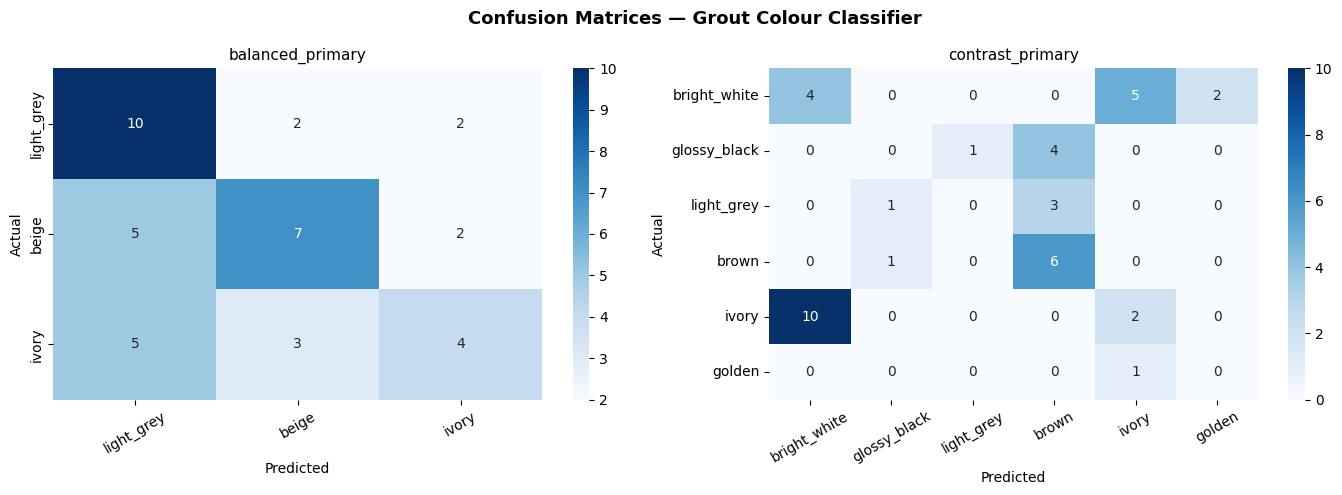

In [19]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrices — Grout Colour Classifier", fontsize=13, fontweight="bold")

for ax, target in zip(axes, cls_targets):
    res = clf_results[target]
    present = sorted(set(res["y_te"]) | set(res["y_pr"]))
    names   = [label_names[l] for l in present if l < len(label_names)]
    cm = confusion_matrix(res["y_te"], res["y_pr"], labels=present)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=names, yticklabels=names)
    ax.set_title(target, fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Pipeline Demo — End-to-End Prediction

This section demonstrates a full inference run using a single input scenario.

In [20]:
def predict_full_scenario(
    area_sqft, tile_length_in, tile_width_in, tile_thickness_mm,
    location, tile_hex
):
    """
    Full end-to-end prediction pipeline.
    Returns estimated material quantities and grout colour recommendations.
    """
    # 1. Derive colour properties
    lightness = get_lightness(tile_hex)
    tone      = get_tone(tile_hex)

    # 2. Build feature row
    row = {
        "area_sqft":             area_sqft,
        "tile_length_in":        tile_length_in,
        "tile_width_in":         tile_width_in,
        "tile_thickness_mm":     tile_thickness_mm,
        "location_floor":        1 if location=="floor"        else 0,
        "location_inside_wall":  1 if location=="inside_wall"  else 0,
        "location_outside_wall": 1 if location=="outside_wall" else 0,
        "tone_cool":    1 if tone=="cool"    else 0,
        "tone_neutral": 1 if tone=="neutral" else 0,
        "tone_warm":    1 if tone=="warm"    else 0,
        "lightness_dark":   1 if lightness=="dark"   else 0,
        "lightness_light":  1 if lightness=="light"  else 0,
        "lightness_medium": 1 if lightness=="medium" else 0,
    }
    X_new = pd.DataFrame([row])[feature_cols]

    # 3. Regression prediction
    reg_pred = rf_reg.predict(X_new)[0]
    clips_pred, grout_vol_pred, grout_tubes_pred = reg_pred

    # 4. Classification prediction
    balanced_label = clf_results["balanced_primary"]["model"].predict(X_new)[0]
    contrast_label = clf_results["contrast_primary"]["model"].predict(X_new)[0]

    balanced_name = label_names[balanced_label] if 0<=balanced_label<len(label_names) else "unknown"
    contrast_name = label_names[contrast_label] if 0<=contrast_label<len(label_names) else "unknown"
    seamless_prim = generate_primary_recommendations(tile_hex, lightness, tone)["seamless"]

    # 5. Rule-based grout width
    min_gw = get_min_grout_width(tile_length_in, location)

    # 6. Display
    print("=" * 55)
    print("   AI MATERIAL ESTIMATION & RECOMMENDATION SYSTEM")
    print("=" * 55)
    print(f"  Input Scenario")
    print(f"    Area          : {area_sqft} sq ft")
    print(f"    Tile Size     : {tile_length_in}" + f"×{tile_width_in} inches")
    print(f"    Thickness     : {tile_thickness_mm} mm")
    print(f"    Location      : {location}")
    print(f"    Tile Colour   : {tile_hex} ({lightness}, {tone})")
    print("-" * 55)
    print(f"  Material Estimates (ML Predicted)")
    print(f"    Clips Required  : {int(clips_pred):,}")
    print(f"    Clip Boxes      : {math.ceil(int(clips_pred)/200)}")
    print(f"    Grout Volume    : {grout_vol_pred:,.1f} mL")
    print(f"    Grout Tubes     : {int(grout_tubes_pred)}")
    print(f"    Min Grout Width : {min_gw} mm")
    print("-" * 55)
    print(f"  Grout Colour Recommendations")
    if isinstance(seamless_prim, dict):
        print(f"    Seamless        : {seamless_prim.get('hex','N/A')} (rule-based)")
    else:
        print(f"    Seamless        : No match in product catalogue")
    print(f"    Balanced        : {balanced_name} (ML predicted)")
    print(f"    Contrast        : {contrast_name} (ML predicted)")
    print("=" * 55)

# Run demo
predict_full_scenario(
    area_sqft=2500,
    tile_length_in=24,
    tile_width_in=24,
    tile_thickness_mm=10.0,
    location="floor",
    tile_hex="#F5F5DC"   # beige tile
)

   AI MATERIAL ESTIMATION & RECOMMENDATION SYSTEM
  Input Scenario
    Area          : 2500 sq ft
    Tile Size     : 24×24 inches
    Thickness     : 10.0 mm
    Location      : floor
    Tile Colour   : #F5F5DC (light, neutral)
-------------------------------------------------------
  Material Estimates (ML Predicted)
    Clips Required  : 1,458
    Clip Boxes      : 8
    Grout Volume    : 9,394.3 mL
    Grout Tubes     : 28
    Min Grout Width : 2.5 mm
-------------------------------------------------------
  Grout Colour Recommendations
    Seamless        : #FFFFFF (rule-based)
    Balanced        : light_grey (ML predicted)
    Contrast        : brown (ML predicted)


In [21]:
# Second demo scenario
predict_full_scenario(
    area_sqft=800,
    tile_length_in=12,
    tile_width_in=12,
    tile_thickness_mm=8.5,
    location="inside_wall",
    tile_hex="#000000"   # black tile
)

   AI MATERIAL ESTIMATION & RECOMMENDATION SYSTEM
  Input Scenario
    Area          : 800 sq ft
    Tile Size     : 12×12 inches
    Thickness     : 8.5 mm
    Location      : inside_wall
    Tile Colour   : #000000 (dark, neutral)
-------------------------------------------------------
  Material Estimates (ML Predicted)
    Clips Required  : 2,384
    Clip Boxes      : 12
    Grout Volume    : 13,401.4 mL
    Grout Tubes     : 41
    Min Grout Width : 2.0 mm
-------------------------------------------------------
  Grout Colour Recommendations
    Seamless        : #000000 (rule-based)
    Balanced        : beige (ML predicted)
    Contrast        : bright_white (ML predicted)


---
## 8. Results Summary

In [22]:
print("\n" + "="*60)
print("  PHASE 3 RESULTS SUMMARY")
print("="*60)
print("\n[A] REGRESSION — Material Estimation")
print(f"  Algorithm   : Random Forest Regressor")
print(f"  n_estimators: 200  |  max_depth: 10  |  min_samples_leaf: 2")

for i, col in enumerate(reg_targets):
    y_true = y_reg_test[col].values
    y_pr   = y_pred_reg[:, i]
    mae  = mean_absolute_error(y_true, y_pr)
    r2   = r2_score(y_true, y_pr)
    print(f"  {col:<20} | MAE={mae:.2f}  R²={r2:.4f}")

print("\n[B] CLASSIFICATION — Grout Colour Recommender")
print(f"  Algorithm   : Random Forest Classifier")
print(f"  n_estimators: 200  |  max_depth: 10  |  class_weight: balanced")
for t, res in clf_results.items():
    print(f"  {t:<25} | Accuracy={res['acc']:.4f}")

print("\n[C] OUTPUT MODES")
print("  Seamless grout  : Rule-based (Phase 2 logic)")
print("  Balanced grout  : ML Classifier")
print("  Contrast grout  : ML Classifier")
print("  Material qty    : ML Regressor")
print("  Min grout width : Domain rule lookup table")
print("="*60)


  PHASE 3 RESULTS SUMMARY

[A] REGRESSION — Material Estimation
  Algorithm   : Random Forest Regressor
  n_estimators: 200  |  max_depth: 10  |  min_samples_leaf: 2
  clips                | MAE=7464.35  R²=0.7004
  grout_volume_ml      | MAE=36634.12  R²=0.7676
  grout_tubes          | MAE=111.05  R²=0.7676

[B] CLASSIFICATION — Grout Colour Recommender
  Algorithm   : Random Forest Classifier
  n_estimators: 200  |  max_depth: 10  |  class_weight: balanced
  balanced_primary          | Accuracy=0.5250
  contrast_primary          | Accuracy=0.3000

[C] OUTPUT MODES
  Seamless grout  : Rule-based (Phase 2 logic)
  Balanced grout  : ML Classifier
  Contrast grout  : ML Classifier
  Material qty    : ML Regressor
  Min grout width : Domain rule lookup table


---
## 9. Challenges Faced

| # | Challenge | Resolution |
|---|---|---|
| 1 | **Small dataset (200 rows)** | Used Random Forest (ensemble → less variance), added 5-fold cross-validation |
| 2 | **Seamless primary returns dict, not string** | Kept seamless as rule-based; only balanced & contrast handled by classifier |
| 3 | **Class imbalance in colour labels** | Used `class_weight='balanced'` in RandomForestClassifier |
| 4 | **Multi-output regression** | RandomForestRegressor natively supports multi-output via single `.fit()` call |
| 5 | **One-hot columns absent for rare categories** | Feature list is filtered at runtime to only include columns that exist in the dataframe |

---
## 10. Save Artefacts

In [24]:
# Save dataset
df_raw.to_csv("F26-10_dataset_phase3.csv", index=False)

# Save models
joblib.dump(rf_reg, "F26-10_regression_model.pkl")
joblib.dump(clf_results["balanced_primary"]["model"], "F26-10_balanced_classifier.pkl")
joblib.dump(clf_results["contrast_primary"]["model"], "F26-10_contrast_classifier.pkl")

print(" Dataset saved  →  F26-10_dataset_phase3.csv")
print(" Models saved   →  F26-10_regression_model.pkl")
print("                     F26-10_balanced_classifier.pkl")
print("                     F26-10_contrast_classifier.pkl")

 Dataset saved  →  F26-10_dataset_phase3.csv
 Models saved   →  F26-10_regression_model.pkl
                     F26-10_balanced_classifier.pkl
                     F26-10_contrast_classifier.pkl
